# Capstone: Define and Solve an ML Problem

In [1]:
import pandas as pd
import numpy as np
import os 
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
import tensorflow.keras as keras
from sklearn.preprocessing import StandardScaler
import time

**Note**: As you work through the notebook, you can import additional packages as needed.

## Overview


In this capstone assignment, you will follow the machine learning life cycle and implement one of the supervised learning models you have learned so far in this course, along with a neural network, to solve a predictive problem.

This capstone spans two lab sessions.

- **Unit 5 Lab:** You will define a machine learning problem, explore and prepare your data, and train, test, evaluate and improve a traditional machine learning model (Parts 1–5).
- **Unit 6 Lab:** After completing Unit 6 on neural networks, you will apply a neural network to the same problem and compare the two approaches (Parts 6–7).

There is a checkpoint at the end of Part 5 that marks where to stop during the Unit 5 lab.

You will complete the following:

1. Choose your Data Set and Build Your DataFrame
2. Define Your ML Problem
3. Understand Your Data
4. Prepare Your Data
5. Train, Test, Evaluate and Improve a Traditional Machine Learning Model *(Unit 5 lab)*
6. Train, Test, Evaluate and Improve Neural Network *(Unit 6 lab)*
7. Compare Your Models and Reflect *(Unit 6 lab)*

**This is an individual assignment.** You are welcome to discuss ideas with your peers, but the code and written responses you submit must be your own.

**Note:** This capstone is intentionally less scaffolded than your weekly labs; that is by design. You are expected to make your own implementation choices, add code cells as needed, and document your reasoning throughout.

## Part 1: Choose Your Data Set and Build Your DataFrame


You will choose one of two data sets to work with for this capstone. In both cases, you will be solving a supervised learning binary classification problem by predicting one of two possible class labels. Both data sets have been used earlier in the course, so you are already familiar with their structure. 

**Option A: Census Income Data** (`censusData.csv`)
This data set contains demographic and employment information from the 1994 U.S. Census. You will use it to predict whether an individual's annual income exceeds $50,000. Your label column is `income_binary`, which contains two values: `<=50K` and `>50K`. You will need to convert this column into a binary numeric label (for example, 0 and 1) during data preparation.

**Option B: Airbnb NYC Listings Data** (`airbnbListingsData.csv`)
This data set contains information about Airbnb listings in New York City. You will use it to predict whether a listing is high-priced. The data set includes a new `price_category` column that classifies each listing as either "high price" or "low price" based on whether the listing’s price falls above or below the 75th percentile of all listing prices. Listings at or above the 75th percentile are labeled as `high`, while the remaining listings are labeled as `low`. You will need to convert this column into a binary numeric label (for example, 0 and 1) during data preparation.

**Note:**  These versions of the data sets differ slightly from the versions you have worked with in this program. For example, they may not include some of the preprocessing necessary for specific models. 

#### Load a Data Set and Save it as a Pandas DataFrame

The code cell below contains filenames (path + filename) for the two data sets available to you.

<b>Task:</b> In the code cell below, load your chosen data set using `pd.read_csv()` and save it to a DataFrame named `df`. Then call `df.head()` to inspect the first few row of the data set.

In [4]:
# File paths for both data sets
census_filename = os.path.join(os.getcwd(), "data_capstone", "censusData.csv")
airbnb_filename = os.path.join(os.getcwd(), "data_capstone", "airbnbListingsData.csv")

# Load your chosen dataset and save it to df
df = pd.read_csv(airbnb_filename)

df.head()


,name,description,neighborhood_overview,host_name,host_location,host_about,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,...,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,n_host_verifications,price_category
0,Skylit Midtown Castle,"Beautiful, spacious skylit studio in the heart...",Centrally located in the heart of Manhattan ju...,Jennifer,"New York, New York, United States",A New Yorker since 2000! My passion is creatin...,0.80,0.17,True,8.0,...,4.86,4.41,False,3,3,0,0,0.33,9,low
1,"Whole flr w/private bdrm, bath & kitchen(pls r...","Enjoy 500 s.f. top floor in 1899 brownstone, w...",Just the right mix of urban center and local n...,LisaRoxanne,"New York, New York, United States",Laid-back Native New Yorker (formerly bi-coast...,0.09,0.69,True,1.0,...,4.71,4.64,False,1,1,0,0,4.86,6,low
2,"Spacious Brooklyn Duplex, Patio + Garden",We welcome you to stay in our lovely 2 br dupl...,NaN,Rebecca,"Brooklyn, New York, United States","Rebecca is an artist/designer, and Henoch is i...",1.00,0.25,True,1.0,...,4.50,5.00,False,1,1,0,0,0.02,3,high
3,Large Furnished Room Near B'way,Please don’t expect the luxury here just a bas...,"Theater district, many restaurants around here.",Shunichi,"New York, New York, United States",I used to work for a financial industry but no...,1.00,1.00,True,1.0,...,4.87,4.36,False,1,0,1,0,3.68,4,low
4,Cozy Clean Guest Room - Family Apt,"Our best guests are seeking a safe, clean, spa...",Our neighborhood is full of restaurants and ca...,MaryEllen,"New York, New York, United States",Welcome to family life with my oldest two away...,NaN,NaN,True,1.0,...,4.94,4.92,False,1,0,1,0,0.87,7,low


## Part 2: Define Your ML Problem

The first step of the machine learning life cycle involves defining your business problem. In the markdown cell below, you will clearly define what you are trying to predict and why it matters. 

<b>Task</b>: In the markdown cell below, answer all of the following questions:

1. Which data set did you choose?
2. What is your label? What are you predicting?
3. What features do you plan to use? (This list may change after you explore your data.)
5. Why does this problem matter? Using the business brief you read in the lab overview page, explain how the organization described there could use a model that predicts this label to create value or inform decisions for their client.

1- I chose the airbnb NYC listings data set.

2- My label is price_category. I will transform it into a binary numeric column with 1 being high and 0 beign low. I am predicting whether a listing is high-priced, which means it is at or above the 75th percentile of listing prices.

3- I plan to use features including location (neighbourhood_group_cleansed), room/property type (room_type, accommodates, bathrooms, bedrooms, beds), host characteristics (host_is_superhost, host_response_rate, host_acceptance_rate, host_listings_count, host_total_listings_count, host_has_profile_pic, host_identity_verified, n_host_verifications, instant_bookable), and review metrics (review_scores_rating, review_scores_cleanliness, review_scores_checkin, review_scores_communication, review_scores_location, review_scores_value, number_of_reviews, reviews_per_month). Price is not included because it is used to derive the label.

4- Trove Analytics helps hospitality clients understand pricing of short-term rentals. Their client, which is a hospitality investment group classifies listings into pricing tiers manually. This process is slow and subjective, and does not match the client's growing portfolio. The organization could use a model that predicts whether a listing is high-priced, as it would allow them to automate the triage step, saving time, manual work, and improving consistency. 

## Part 3: Understand Your Data

Now that you have defined your problem, perform exploratory data analysis (EDA) with that problem in mind. Consider the following as you inspect your data:

1. What data preparation techniques would you like to use? These data preparation techniques may include:

    * handling missing values
    * finding and replacing outliers
    * performing feature engineering techniques such as one-hot encoding on categorical features
    * selecting appropriate features and removing irrelevant features
    * addressing class imbalance


2. What machine learning model would you like to use that is suitable for your predictive problem and data?
   * You may use one of the following models that you have worked with so far:
        - K-Nearest Neighbors (KNN)
        - Decision Tree
        - Logistic Regression
   * Are there other data preparation techniques that you will need to apply to build a balanced modeling data set for your problem and model? For example, will you need to scale your data?
 

3. How will you evaluate and improve the model's performance?
    * Are there specific evaluation metrics or methods that are appropriate for your problem, dataset, or selected model?
    
<b>Task</b>: In the code cells below, use the techniques you have learned in this course to inspect and analyze your data.

<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

### Class Imbalance

Examine the distribution of your label column to determine whether class imbalance is present. Use at least one visualization to show the class distribution. In the **EDA Summary** below, you will discuss how you plan to address any observed imbalance during data preparation.

low     20785
high     7237
Name: price_category, dtype: int64
low     0.741739
high    0.258261
Name: price_category, dtype: float64


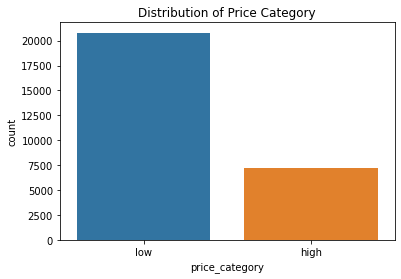

In [5]:
print(df['price_category'].value_counts())
print(df['price_category'].value_counts(normalize=True))
sns.countplot(data=df, x='price_category')
plt.title('Distribution of Price Category')
plt.show()

### Inspect and Analyze Your Data

Explore your features. Use summary statistics and visualizations to understand how your features are distributed and how they relate to the label. Identify issues such as missing values, outliers, or a feature that is irrelevant or redundant.

Think of the different techniques you have used to inspect and analyze your data in this course. These include using Pandas to apply data filters, using the Pandas `describe()` method to get insight into key statistics for each column, using the Pandas `dtypes` property to inspect the data type of each column, and using Matplotlib and Seaborn to detect outliers and visualize relationships between features and labels. 

Use at least one plot that visualizes a relationship between features and the label.

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct}).sort_values('missing_pct', ascending=False)

,missing_count,missing_pct
host_response_rate,11843,42.263222
host_acceptance_rate,11113,39.658126
host_about,10945,39.058597
neighborhood_overview,9816,35.029620
bedrooms,2918,10.413247
beds,1354,4.831918
description,570,2.034116
host_location,60,0.214117
name,5,0.017843
availability_90,0,0.000000


In [7]:
df.dtypes

name                                             object
description                                      object
neighborhood_overview                            object
host_name                                        object
host_location                                    object
host_about                                       object
host_response_rate                              float64
host_acceptance_rate                            float64
host_is_superhost                                  bool
host_listings_count                             float64
host_total_listings_count                       float64
host_has_profile_pic                               bool
host_identity_verified                             bool
neighbourhood_group_cleansed                     object
room_type                                        object
accommodates                                      int64
bathrooms                                       float64
bedrooms                                        

In [8]:
df.describe()

,host_response_rate,host_acceptance_rate,host_listings_count,host_total_listings_count,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,...,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,n_host_verifications
count,16179.000000,16909.000000,28022.000000,28022.000000,28022.000000,28022.000000,25104.000000,26668.000000,28022.000000,28022.000000,...,28022.000000,28022.000000,28022.000000,28022.000000,28022.000000,28022.000000,28022.000000,28022.000000,28022.000000,28022.000000
mean,0.906901,0.791953,14.554778,14.554778,2.874491,1.142174,1.329708,1.629556,154.228749,18.689387,...,4.814300,4.808041,4.750393,4.647670,9.581900,5.562986,3.902077,0.048283,1.758325,5.169510
std,0.227282,0.276732,120.721287,120.721287,1.860251,0.421132,0.700726,1.097104,140.816605,25.569151,...,0.438603,0.464585,0.415717,0.518023,32.227523,26.121426,17.972386,0.442459,4.446143,2.028497
min,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,29.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.010000,1.000000
25%,0.940000,0.680000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,70.000000,2.000000,...,4.810000,4.810000,4.670000,4.550000,1.000000,0.000000,0.000000,0.000000,0.130000,4.000000
50%,1.000000,0.910000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,115.000000,30.000000,...,4.960000,4.970000,4.880000,4.780000,1.000000,1.000000,0.000000,0.000000,0.510000,5.000000
75%,1.000000,1.000000,3.000000,3.000000,4.000000,1.000000,1.000000,2.000000,180.000000,30.000000,...,5.000000,5.000000,5.000000,5.000000,3.000000,1.000000,1.000000,0.000000,1.830000,7.000000
max,1.000000,1.000000,3387.000000,3387.000000,16.000000,8.000000,12.000000,21.000000,1000.000000,1250.000000,...,5.000000,5.000000,5.000000,5.000000,421.000000,308.000000,359.000000,8.000000,141.000000,13.000000


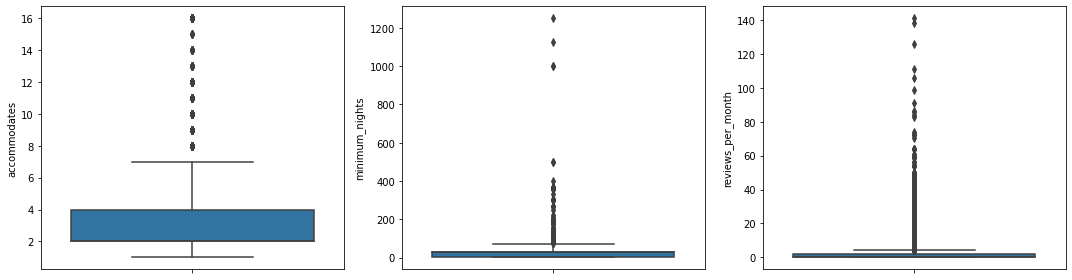

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.boxplot(data=df, y='accommodates', ax=axes[0])
sns.boxplot(data=df, y='minimum_nights', ax=axes[1])
sns.boxplot(data=df, y='reviews_per_month', ax=axes[2])
plt.tight_layout()
plt.show()

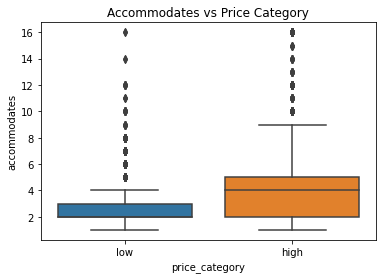

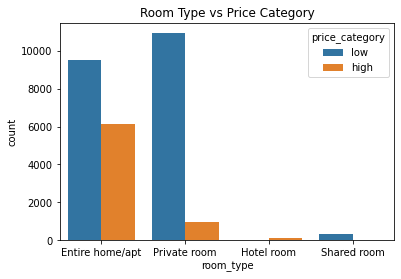

In [10]:
sns.boxplot(data=df, x='price_category', y='accommodates')
plt.title('Accommodates vs Price Category')
plt.show()

sns.countplot(data=df, x='room_type', hue='price_category')
plt.title('Room Type vs Price Category')
plt.show()

### EDA Summary

<b>Task</b>: In the markdown cell below, summarize the key findings from your data exploration. Describe any patterns, anomalies, or data quality issues you identified and explain how those findings may influence your data preparation decisions. For example, your exploration may affect how you handle missing values, address class imbalance, or determine which features to keep or remove.

-Class imbalance: The label is imbalanced with 74.2% of listings being "low" price and 25.8% being "high" price. The imbalance is not significant enough to perform resampling, but it means accuracy alone would be a misleading metric, since a model that always predicts "low" would already score approximately 74%. I will make sure to prioritize precision, recall, and F1 when I evaluate the performance.

-Missing values: the host_response_rate and host_acceptance_rate have a large missingness. Due to this, I will impute with the median and add a binary "missing" indicator column, instead of dropping the feature, since host responsiveness could relate to the price tier. bedrooms (10.4%) and beds (4.8%) have more moderate missingness and I'll impute these with the median directly. Free-text fields (description, neighborhood_overview, host_about) also have missing values, but since these are excluded from modeling, it doesn't affect feature preparation.

-Outliers: Several numeric features show significant right-skew with extreme outliers. minimum_nights ranges from 1 to 1,250 nights (over 3 years), with the 75th percentile at just 30. reviews_per_month similarly ranges from 0.01 to 141 with a mean of only 1.76, indicating a long tail of unusually active listings. host_listings_count has a mean of 14.6 but a max of 3,387, likely reflecting large property-management companies rather than individual hosts. I plan to cap these at a reasonable percentile during data preparation instead of dropping the rows, to avoid losing data while limiting the influence of extreme values.

-Feature-label relationships: Listings with more capacity tend to be priced higher. The median accommodates value for "high" price listings is noticeably above that of "low" price listings, with "high" listings clustering around 4 guests versus 2 for "low." Room type also shows that "Entire home/apt" listings make up a much larger share of "high" price listings, while "Private room" listings are  "low" price. "Hotel room" and "Shared room" are rare categories with very few listings overall, which I'll keep in mind during one-hot encoding since sparse categories can be noisy for the model.

-The host_listings_count and host_total_listings_count have identical summary statistics, which suggests that they are duplicates so I will remove one. I'm also excluding price and free-text fields.

-The dataset has a mix of object, bool, and numeric types. I will one-hot encode the categorical columns and convert booleans to 0/1 integers before modeling. Given the mix of scales across numeric features, I will apply feature scaling.

### Ethical Considerations:

Machine learning models can cause harm when they reflect or amplify biases in the data they are trained on. 

<b>Task</b>: In the markdown cell below, answer both of the following questions:

1. What biases or ethical concerns might be present in your dataset? Think about who collected the data, how it was collected, and which groups of people appear in it. Are there features in the dataset that could serve as proxies for protected characteristics like race, gender, or socioeconomic status?
2. Who could be harmed by a model that makes incorrect predictions on this data, and how? Be specific about which groups are most at risk and what the real-world consequences of errors might look like.

1.This data reflects patterns in the nyc rental market, which is itself shaped by inequities. neighbourhood_group_cleansed could be a proxy for socioeconomic status or race. Review-based features could also perpetuate bias, since guests sometimes rate hosts differently based on their race, ethnicity, and gender. Moreover, the data includes listings that hosts chose to include on Airbnb, so it may not represent all housing types equally.

2.If the model makes an error in price prediction and predicts a high price for listings in lower-income neighborhoods, those listings could get less marketing investment, which reinforces existing inequalities. If it predicts a higher price in gentrifying areas, it could contribute to displacement.  

## Part 4: Prepare Your Data

<b>Task</b>: In the code cell below, prepare your data for modeling. The specific steps you take will depend on what you found during your EDA and which model you plan to use. 

<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

In [12]:
drop_cols = [
    'name', 'description', 'neighborhood_overview', 'host_about',
    'host_name', 'host_location',
    'amenities',
    'price',
    'host_total_listings_count',
]
df_model = df.drop(columns=drop_cols)
df_model.shape

(28022, 42)

In [13]:
df_model['price_category'] = df_model['price_category'].map({'low': 0, 'high': 1})
df_model['price_category'].value_counts()

0    20785
1     7237
Name: price_category, dtype: int64

In [14]:
for col in ['host_response_rate', 'host_acceptance_rate']:
    df_model[f'{col}_missing'] = df_model[col].isnull().astype(int)
    df_model[col] = df_model[col].fillna(df_model[col].median())
for col in ['bedrooms', 'beds']:
    df_model[col] = df_model[col].fillna(df_model[col].median())
df_model.isnull().sum().sum()   

0

In [15]:
for col in ['minimum_nights', 'reviews_per_month', 'host_listings_count']:
    cap = df_model[col].quantile(0.99)
    df_model[col] = df_model[col].clip(upper=cap)

df_model[['minimum_nights', 'reviews_per_month', 'host_listings_count']].describe()

,minimum_nights,reviews_per_month,host_listings_count
count,28022.000000,28022.000000,28022.000000
mean,17.698272,1.605655,8.603276
std,14.990821,2.914129,27.798551
min,1.000000,0.010000,0.000000
25%,2.000000,0.130000,1.000000
50%,30.000000,0.510000,1.000000
75%,30.000000,1.830000,3.000000
max,74.370000,18.965800,177.000000


In [16]:
bool_cols = df_model.select_dtypes(include='bool').columns
df_model[bool_cols] = df_model[bool_cols].astype(int)
categorical_cols = ['room_type', 'neighbourhood_group_cleansed']
df_model = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)
df_model.shape

(28022, 49)

### Data Preparation Summary:

<b>Task</b>: In the markdown cell below, document the data preparation steps you took. For each decision, explain why you made it. For example, why did you handle missing values the way you did? Why did you keep or remove certain features? If a preparation step depends on the model you selected (for example, scaling for KNN but not for a decision tree), explain that as well.

I dropped free-text fields such as description, neighborhood_overview, host_about, and amenities since they would need NLP preprocessing to be useful. I also dropped host_name and host_location since they're identifiers, and price since it was used to derive the label directly, so keeping it would be data leakage. I dropped host_total_listings_count since it was redundant with host_listings_count.

For missing values, host_response_rate and host_acceptance_rate were both missing more than 40% of values, so I imputed with the median and added a binary "missing" indicator column, so the model can still learn from cases where a host simply never responded, which might itself be informative. bedrooms and beds had much less missingness (10% and 5%), so I imputed those with the median directly without an indicator.

A few numeric columns had extreme outliers. minimum_nights went up to 1,250 days, reviews_per_month up to 141, and host_listings_count up to 3,387. Instead of dropping these rows and losing data, I capped each at its 99th percentile so extreme values wouldn't disproportionately influence the model.

I converted boolean columns to 0/1 integers, and one-hot encoded room_type and neighbourhood_group_cleansed, dropping the first category of each to avoid multicollinearity.

I didn't scale the numeric features, since I'm using a Decision Tree, which splits on feature thresholds rather than distances. This would be a different story for a distance-based model like KNN or a coefficient-based model like Logistic Regression, both of which are sensitive to feature scale and would need it.

## Part 5: Train, Test, Evaluate, and Improve a Traditional Machine Learning Model

Now you will train, test and evaluate your model. You will also use model selection techniques to improve your model's performance by identifying the optimal hyperparameter configuration.

<b>Task</b>: In the code cells below, do the following:

1. Create labeled examples from the dataset
2. Create training and test sets out of the labeled examples 
3. Train, test and evaluate your model 
    * You must evaluate your model using accuracy and F1 score. Use `accuracy_score` and `f1_score` from `sklearn.metrics`. For the F1 score, use `average='binary'` since this is a binary classification problem. You will compare your model's performance to that of a neural network later in this capstone. Save the results of your evaluation metrics to variables for later comparison.
    * You may use additional evaluation metrics of your choosing.
4. Perform model selection through grid search cross-validation to identify optimal hyperparameter values for your model
5. Train, test and evaluate a final version of your model using the optimal hyperparameter configuration.
6. Interpret your model's outputs in the context of the business problem. Depending on the model you chose, this might mean:
    * KNN: Describe what your model's performance metrics tell you about its behavior. For example: How does accuracy change as you vary k? What does that suggest about the structure of your data?
    * Decision Tree: print or plot feature importances.
    * Logistic Regression: print or plot the model coefficients.



<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

In [17]:
# Create labeled examples from the dataset
y = df_model['price_category']
X = df_model.drop(columns=['price_category'])
X.shape, y.shape

((28022, 48), (28022,))

In [18]:
# Create training and test sets out of the labeled examples 
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train.shape, X_test.shape

((22417, 48), (5605, 48))

In [19]:
# Train, test and evaluate your model
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score

dt_baseline = DecisionTreeClassifier(random_state=42)
dt_baseline.fit(X_train, y_train)

y_pred_baseline = dt_baseline.predict(X_test)

acc_baseline = accuracy_score(y_test, y_pred_baseline)
f1_baseline = f1_score(y_test, y_pred_baseline, average='binary')

print(f"Baseline Accuracy: {acc_baseline:.4f}")
print(f"Baseline F1 Score: {f1_baseline:.4f}")

Baseline Accuracy: 0.7971
Baseline F1 Score: 0.6165


In [20]:
# Perform model selection through grid search cross-validation (GridSearchCV)
# to identify optimal hyperparameter values for your model
from sklearn.model_selection import GridSearchCV
param_grid = {
    'max_depth': [3, 5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
print("Best parameters:", grid_search.best_params_)
print("Best CV F1 score:", grid_search.best_score_)

Best parameters: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5}
Best CV F1 score: 0.6351523639151446


In [21]:
# Train, test and evaluate a final version of your model using the optimal hyperparameter values.
dt_final = grid_search.best_estimator_
y_pred_final = dt_final.predict(X_test)
acc_final = accuracy_score(y_test, y_pred_final)
f1_final = f1_score(y_test, y_pred_final, average='binary')
print(f"Final Accuracy: {acc_final:.4f}")
print(f"Final F1 Score: {f1_final:.4f}")

Final Accuracy: 0.8264
Final F1 Score: 0.6296


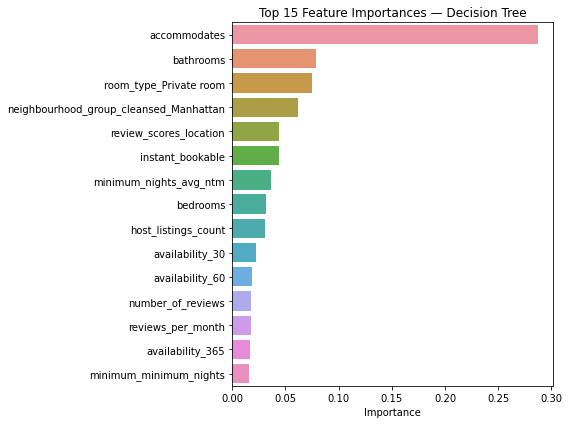

accommodates                              0.287377
bathrooms                                 0.078730
room_type_Private room                    0.074774
neighbourhood_group_cleansed_Manhattan    0.061456
review_scores_location                    0.044332
instant_bookable                          0.044043
minimum_nights_avg_ntm                    0.036183
bedrooms                                  0.032053
host_listings_count                       0.030419
availability_30                           0.022578
availability_60                           0.018919
number_of_reviews                         0.017684
reviews_per_month                         0.017400
availability_365                          0.016565
minimum_minimum_nights                    0.016092
dtype: float64

In [22]:
# Interpret your model's outputs 
importances = pd.Series(dt_final.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False).head(15)
plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index)
plt.title('Top 15 Feature Importances — Decision Tree')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()
importances

### Model Reflection:

<b>Task</b>: In the markdown cell below, answer the following questions:

1. Which model did you choose and why? Reference your problem and data characteristics in your explanation.
2. What did you learn through the model selection process?
3. How do you interpret your model's outputs? What do the predictions or coefficients or feature importances actually mean in the context of your problem?
4. Are there any fairness or ethical concerns with your model? Who might be harmed by incorrect predictions, and are any groups more likely to be affected?

1.I chose a Decision Tree model since my features have a combination of categorical and numeric data, which trees handle without the need for scaling or distance-based assumptions. Moreover, a tree produces feature importances, giving Trove Analytics' client an interpretable explanation for why a listing gets flagged premium, not just a bare prediction.

2.The baseline model scored 79.71% accuracy and 0.6165 F1. After grid search across max_depth, min_samples_split, min_samples_leaf, and criterion, the best configuration which was max_depth=10, min_samples_split=5, min_samples_leaf=1, criterion='gini' improved performance to 82.64% accuracy and 0.6296 F1 on the test set. The gap between the baseline and tuned model suggests the default tree was slightly overfitting, letting it grow without limits captures noise in the training data that doesn't generalize. Capping the max_depth at 10 allowed better generalization. The small F1 improvement versus the larger accuracy jump implies that the model still finds the minority "high" class harder to predict than the majority "low" class.

3.accommodates has the highest importance, and is thus the most influential feature. This makes sense given that the higher the capacity of a listing, the higher they are likely priced. bathrooms and room_type_Private room are also very important after accommodates. neighbourhood_group_cleansed_Manhattan also ranks high, suggesting that location plays an important role. Thus, listing features play a bigger role than features such as host reviews.  

4.Seeing how neighbourhood_group_cleansed_Manhattan shows up as a very important feature means that the predicted price relies on borough-level location This means the model could reinforce existing borough-level inequalities if these predictions are used in the marketing decision making priorities. This furthers the gap for hosts, despite listing quality based on the location. 

---
## ✔️ Unit 5 Checkpoint

**Stop here.** If you have completed Parts 1 through 5, you are done with the Unit 5 portion of this capstone.

Parts 6 and 7 require you to train and evaluate a neural network. You will learn about neural networks in the Unit 6 asynchronous content. Do not start Part 6 until you have completed that material and your lab facilitator has directed you to continue. Do not submit your work for grading until you complete Parts 6 and 7.

Make sure your notebook is saved before you close it.

---
## Part 6: Train, Test, Evaluate and Improve a Neural Network

> **⚠️ Before you write any code in Part 6, do this first.**
> 
> Your notebook does not retain variables between sessions. All of your variables and everything else need to be restored to memory before any code below will work.
> 
> Go to **Kernel > Restart & Run All** to re-run Parts 1 through 5, then scroll back here to continue. If you skip this step, you will see a `NameError` on the first code cell below.

Now you will apply a neural network to the same problem and dataset. You will use Keras to build a feedforward neural network for binary classification.

The scaffolding below will walk you through the steps. Where you see a **Task**, fill in the code. Where you see a **Decision**, you are making an independent choice about your architecture or training process. For each decision, add a comment explaining what you chose and why.


### Prepare Your Data for the Neural Network

Neural networks require all input features to be numeric and scaled. If your features are on very different scales (for example, one feature ranges from 0 to 90 and another from 0 to 99999), the model may train less effectively and have difficulty learning meaningful patterns from the data.

Before training your network, create scaled versions of your training and test data. Use `StandardScaler()` from `sklearn.preprocessing` to standardize your features: 

<b>Task</b>: Complete the code cell below to fit the scaler on your training data, then transform both training and test sets. Save the results to new variables (for example, `X_train_scaled` and `X_test_scaled`) so your original data remains available for reference.

**Note:** Use your scaled data for all neural network steps below.

In [23]:
# Scale your data for the neural network

# Create the scaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform the training data
X_train_scaled = scaler.fit_transform(X_train)

# Use the same scaler to transform the test data
X_test_scaled = scaler.transform(X_test)

### Step 1: Define Your Model Architecture

You will use the Keras `Sequential` class to build your network. Your network should have:

- An input layer with the correct shape for your data
- At least two hidden layers using the `Dense` class
- An output layer appropriate for binary classification

<b>Task:</b> Create a `Sequential` model object and name it `nn_model`. Then construct and add each layer.

**Decision:** How many hidden layers will you use? How many units in each? What activation function will you use for the hidden layers? Add a comment explaining your choices.

In [24]:
# Get the number of features in your training data
n_features = X_train_scaled.shape[1]

# Create the neural network model
nn_model = keras.Sequential()

# Create the input layer and add the input layer to the 'nn_model' object
nn_model.add(keras.layers.InputLayer(input_shape=(n_features,)))

# Create the hidden layers and add the hidden layers to the 'nn_model' object
# Decision: How many layers? How many units? What activation function?
# Decision: I'm using 2 hidden layers with 64 and 32 units, using ReLU activation. ReLU is the standard choice for hidden layers since it avoids the
# vanishing gradient problem that sigmoid/tanh can run into, and trains faster.
# I chose 64 -> 32 (a funnel shape) since it's a common starting point
# for a tabular dataset of this size, approcimately 48 features and 22k training rows, enough
# capacity to learn patterns without being so large it overfits quickly.
nn_model.add(keras.layers.Dense(64, activation='relu'))
nn_model.add(keras.layers.Dense(32, activation='relu'))


# Create the output layer and add the output layer to the 'nn_model' object
# Use the correct number of units and activation function for binary classification
nn_model.add(keras.layers.Dense(1, activation='sigmoid'))

# Print a summary of your model
nn_model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 64)                3136      
_________________________________________________________________
dense_1 (Dense)              (None, 32)                2080      
_________________________________________________________________
dense_2 (Dense)              (None, 1)                 33        
Total params: 5,249
Trainable params: 5,249
Non-trainable params: 0
_________________________________________________________________


### Step 2:  Define the Optimization Function

<b>Task:</b> In the code cell below, create an optimizer object. Use stochastic gradient descent (SGD) with a learning rate of your choosing.

**Decision:** What learning rate will you use? Add a comment explaining your choice.

In [25]:
# Decision: What learning rate will you use? Add a comment explaining your decision.
# I chose a learning rate of 0.1. In my earlier labs, lr=0.1 outperformed lr=0.01 under a fixed epoch budget and since I'm working with a
# similarly-sized tabular dataset here, I'm starting with the same value.
sgd_optimizer = keras.optimizers.SGD(learning_rate=0.1)

### Step 3: Define the Loss Function

<b>Task:</b> In the code cell below, create a binary cross entropy loss function using `keras.losses.BinaryCrossentropy()`. Use  the parameter `from_logits=False`. 

In [26]:
loss_fn = keras.losses.BinaryCrossentropy(from_logits=False)

### Step 4: Compile the Model

<b>Task:</b> In the code cell below, package the network architecture with the optimizer and the loss function using the `compile()` method. Use the `accuracy` evaluation metric.

In [27]:
nn_model.compile(optimizer=sgd_optimizer, loss=loss_fn, metrics=['accuracy'])

### Step 5: Fit the Model to the Training Data

We will define our own callback class to output information from our model while it is training. Make sure you execute the code cell below so that it can be used in subsequent cells.

In [28]:
class ProgBarLoggerNEpochs(keras.callbacks.Callback):
    
    def __init__(self, num_epochs: int, every_n: int = 50):
        self.num_epochs = num_epochs
        self.every_n = every_n
    
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.every_n == 0:
            s = 'Epoch [{}/ {}]'.format(epoch + 1, self.num_epochs)
            logs_s = ['{}: {:.4f}'.format(k.capitalize(), v)
                      for k, v in logs.items()]
            s_list = [s] + logs_s
            print(', '.join(s_list))


<b>Task:</b> Use the `fit()` method to fit your model to the training data. Save the result to variable `history.`

Use the `validation_split` parameter to reserve a portion of your training data for validation during training (a common choice is `validation_split=0.2`). After each epoch, the model is evaluated on this validation data, allowing you to monitor how well the model generalizes and helping you detect overfitting.

Also, use the the logger class defined above to track training progress.

**Decision:** How many epochs will you train for? Add a comment explaining your choice.

**Note:** This may take a while to run.

In [29]:
# Decision: How many epochs? Add a comment.
# I'm training for 100 epochs. This mirrors the fixed 100 epoch setup I used in my neural network labs
# and gives the model enough passes over the data to
# converge while keeping training time manageable.  

t0 = time.time() # start time

num_epochs = 100

history = nn_model.fit(
    X_train_scaled,
    y_train,
    epochs=num_epochs,
    verbose=0,
    validation_split=0.2,
    callbacks=[ProgBarLoggerNEpochs(num_epochs=num_epochs, every_n=10)]
)


t1 = time.time() # stop time

print('Elapsed time: %.2fs' % (t1-t0))

Epoch [10/ 100], Loss: 0.3045, Accuracy: 0.8638, Val_loss: 0.3431, Val_accuracy: 0.8421
Epoch [20/ 100], Loss: 0.2858, Accuracy: 0.8715, Val_loss: 0.3680, Val_accuracy: 0.8363
Epoch [30/ 100], Loss: 0.2702, Accuracy: 0.8807, Val_loss: 0.3693, Val_accuracy: 0.8421
Epoch [40/ 100], Loss: 0.2531, Accuracy: 0.8888, Val_loss: 0.3869, Val_accuracy: 0.8356
Epoch [50/ 100], Loss: 0.2401, Accuracy: 0.8933, Val_loss: 0.3969, Val_accuracy: 0.8356
Epoch [60/ 100], Loss: 0.2260, Accuracy: 0.8993, Val_loss: 0.4426, Val_accuracy: 0.8354
Epoch [70/ 100], Loss: 0.2157, Accuracy: 0.9059, Val_loss: 0.4648, Val_accuracy: 0.8258
Epoch [80/ 100], Loss: 0.2073, Accuracy: 0.9103, Val_loss: 0.5065, Val_accuracy: 0.8292
Epoch [90/ 100], Loss: 0.1995, Accuracy: 0.9126, Val_loss: 0.5137, Val_accuracy: 0.8392
Epoch [100/ 100], Loss: 0.1862, Accuracy: 0.9184, Val_loss: 0.5427, Val_accuracy: 0.8220
Elapsed time: 124.24s


### Step 6: Visualize Training Performance

<b>Task:</b>  

Create two plots to visualize the model's performance over time:
1. Training loss and validation loss over epochs, on the same axes.
2. Training accuracy and validation accuracy over epochs, on the same axes.

Label your axes and include a legend.

Use the `history` object returned by `fit()` to obtain this information. 



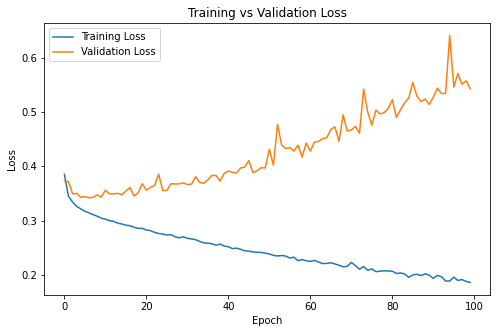

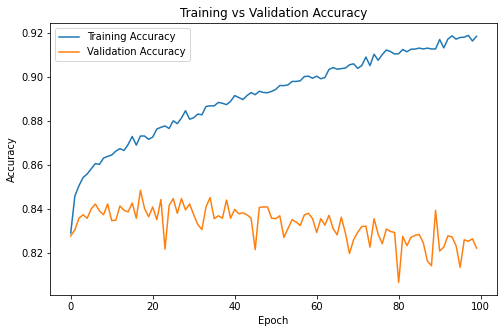

In [30]:
# Plot training loss and validation loss over epochs
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

# Plot training accuracy and validation accuracy over epochs
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

### Step 7: Evaluate the Model's Performance on the Test Set

<b>Task:</b> Use your neural network to generate predictions on the test set and evaluate its performance using accuracy and F1 score. Use `nn_model.predict()` to generate predictions. Since `nn_model.predict()` returns probabilities, apply a threshold of 0.5 to convert probabilities into binary class predictions before computing your metrics. Save your accuracy and F1 score results to clearly named variables so you can compare them to the results from your previous model. Print the results.

In [32]:
# Generate predictions from your neural network using your scaled test data
# nn_model.predict() returns probabilities — apply a threshold of 0.5 to get class labels
y_pred_proba_nn = nn_model.predict(X_test_scaled)
y_pred_nn = (y_pred_proba_nn >= 0.5).astype(int)

In [33]:
# Compute accuracy and F1 score for the neural network and print the results
acc_nn = accuracy_score(y_test, y_pred_nn)
f1_nn = f1_score(y_test, y_pred_nn, average='binary')

print(f"Neural Network Accuracy: {acc_nn:.4f}")
print(f"Neural Network F1 Score: {f1_nn:.4f}")

Neural Network Accuracy: 0.8180
Neural Network F1 Score: 0.6473


#### Neural Network Reflection:

<b>Task:</b> In the markdown cell below, answer the following questions:

1. Walk through the architecture decisions you made: number of layers, number of units, activation functions, learning rate, and number of epochs. Why did you make each of those choices?
2. What did your training curves tell you? Did you see any signs of overfitting or underfitting?
3. How did your neural network perform on the test set? Report your accuracy and F1 score here and note whether the result surprised you given what your training curves showed.

1.I used 2 hidden layers with 64 and 32 units, using ReLU activation, since ReLU trains efficiently and avoids vanishing gradients. The output layer uses a single unit with sigmoid activation, which is appropriate for binary classification. For the optimizer, I used SGD with a learning rate of 0.1, based on earlier experiments where 0.1 converged better than 0.01 within a fixed epoch budget. I trained for 100 epochs to give the model enough passes over the data to learn patterns while keeping training time reasonable.

2.My training curves show overfitting. The training loss decreased to about 0.19 and training accuracy increased to 91.8%, but validation loss increased after epoch 10, ending at 0.54, validation accuracy remained consistent around 82-84% and even dipped sometimes. The growing gap between training and validation performance means the model kept learning patterns specific to the training set that didn't generalize well.

3.On the test set, the model scored 81.80% accuracy and 0.6473 F1. This isn't surprising to me due to the training curves. The overfitting meant the model's later epoch training performance was inflated, so the test results land closer to where validation performance was rather than matching the very high training accuracy.  

## Part 7: Compare Your Models and Reflect

You have now applied two different approaches to the same problem. In this final section, you will put those results side by side and reflect on what you learned.

###  Results Summary

<b>Task:</b> In the code cell below, create a summary table using a Pandas DataFrame that displays each evaluation metric for both models side by side. Use the variables you created for the accuracy and F1 score metrics. The table should make it easy to compare performance at a glance across every metric you computed.

In [34]:
# Build a side-by-side comparison of your two models using the metric variables
results = pd.DataFrame({
    'Metric': ['Accuracy', 'F1 Score'],
    'Decision Tree': [acc_final, f1_final],
    'Neural Network': [acc_nn, f1_nn]
})
print(results.to_string(index=False))

   Metric  Decision Tree  Neural Network
 Accuracy       0.826405        0.818020
 F1 Score       0.629616        0.647303


### Comparative Analysis

<b>Task:</b> In the markdown cell below, write a comparative analysis that addresses the following. 

1. **Performance comparison.** How did the two models perform relative to each other? Which metrics improved, which stayed the same, and which got worse?

2. **Was the added complexity worth it?** Neural networks are more complex to build, tune, and interpret. Given the performance difference you observed, do you think the neural network justified that added complexity for this problem?

3. **Recommendation.** If you were presenting this work to your company and their client as described in the business brief, which model would you recommend deploying and why? Consider not just performance but also interpretability, training time, and what the costs of different types of errors look like for that specific client.

4. **What you would do next.** If you had more time, what would you try to improve your results? This could include trying different architectures, additional preprocessing steps, different features, or techniques to address class imbalance. Be specific.

1.The Decision Tree had slightly higher accuracy (82.6% vs 81.8%), while the Neural Network had a better F1 score (0.6473 vs 0.6296). Since F1 accounts for both precision and recall, this suggests the Neural Network was better at identifying "high" price listings specifically, even though its overall accuracy was marginally lower.

2.No. The Neural Network took 2 minutes to train and required more decisions, while the Decision Tree trained instantly and needed less tuning. Given that the F1 improvement was small and the Decision Tree's accuracy was actually slightly higher, the added complexity of the neural network isn't clearly justified here. The neural network also showed noticeable overfitting, whereas the tuned Decision Tree generalized more predictably.

3.I would recommend the Decision Tree. It's directly interpretable through feature importances, which lets Trove Analytics explain to the client why a listing was flagged as high-priced, something a neural network can't easily provide.  

4.I'd try addressing the class imbalance more directly, using class weighting to see if that improves recall on the "high" price class specifically. I'd also try engineering features from the amenities list such as counting amenities instead of dropping the column. For the neural network, I'd add dropout layers and use early stopping to control the overfitting shown in the training curves, and experiment with a lower learning rate over more epochs to see if it converges more smoothly.

---
## AI Use Attestation

Reflect honestly on how you used AI tools during this capstone. You are expected to have used AI somewhere in your workflow, and your reflection on that use is what will be evaluated: How clearly you describe your choices, how you verified your work, and what you learned from the process. If you chose not to use AI, explain why. Answer each question in the markdown cell below.

1. Where and at what stages of this capstone did you use AI tools, for example, Claude during brainstorming, coding, or debugging? If you chose not to use AI, explain why.
2. Identify one part of the capstone that required the most effort or thought. What made it challenging, and how did you work through it, with AI or without AI? If you used AI at this point, feel free to share a prompt that worked well or one that did not land the way you expected.
3. How did you verify that your work was correct? What did you look for to catch a mistake, whether it came from AI output or your own reasoning?
4. What is one thing you would do differently next time, either in how you approached the capstone or in how you used AI during it?

1.I used Claude to help me debug some issues I ran into.

2.The neural network implementation required the most effort as it was new material. I had to go over course notes to get through it. I asked Claude to help me debug errors that showed when i ran the call.

3.I ran each cell and made sure it did not output errors. I looked back on my notes to catch mistakes. I checked Claude's explanation of the overfitting pattern against the training curve plots themselves.

4.Next time I'd try to form a hypothesis about the bug or pattern myself before asking Claude.